In [1]:
StudentName = '402170013'
StudentID = 'NasimJavdani'

In [ ]:
چون کد هارو از کولب کپی کردم تا توی کگل بتونم از GPU استفاده کنم واسه ی همین جز کد ها چیز دیگری رو کپی نکردم.

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import ResNet50
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score, auc
from sklearn.preprocessing import label_binarize

2026-01-06 23:21:11.587635: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767741671.790815      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767741671.853257      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [8]:

os.listdir("/kaggle/input/archive/flowers")
BASE_DIR = "/kaggle/input/archive/flowers/flowers/flower_photos"

TRAIN_DIR = BASE_DIR + "/train"
VAL_DIR   = BASE_DIR + "/validation"
TEST_DIR  = BASE_DIR + "/test"


In [9]:
import tensorflow as tf

IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [10]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 3540 files belonging to 5 classes.


I0000 00:00:1767741843.677073      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1767741843.677715      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 80 files belonging to 5 classes.
Found 50 files belonging to 5 classes.


In [11]:
# Show different classes of flowers in our dataset
class_names = train_ds.class_names

print("Flower classes:", class_names)

Flower classes: ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


In [12]:
# Show the number of images in each class of flower

class_counts = collections.Counter()

for images, labels in train_ds.unbatch():
    label = labels.numpy()
    class_name = class_names[label]
    class_counts[class_name] += 1

print("Number of images in each flower class:")
for cls in class_names:
    print(f"{cls}: {class_counts[cls]}")

Number of images in each flower class:
daisy: 607
dandelion: 872
roses: 615
sunflowers: 673
tulips: 773


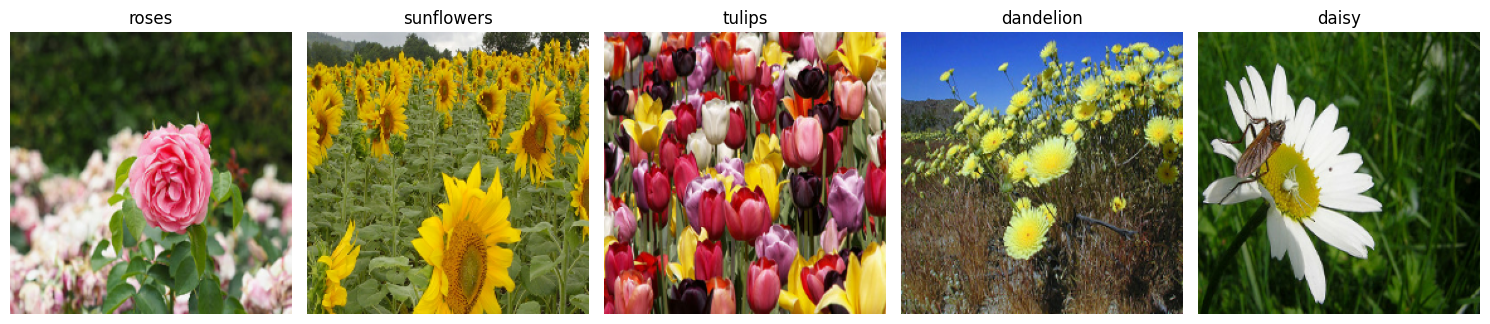

In [13]:
# Show a flower image from each class

plt.figure(figsize=(15, 8))

seen = set()
i = 1

for image, label in train_ds.unbatch():
    class_label = class_names[label.numpy()]

    if class_label not in seen:
        plt.subplot(1, len(class_names), i)
        plt.imshow(image.numpy().astype("uint8"))
        plt.title(class_label)
        plt.axis("off")

        seen.add(class_label)
        i += 1

    if len(seen) == len(class_names):
        break

plt.tight_layout()
plt.show()

In [14]:

train_data = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.8, 1.2],
    zoom_range=[0.9, 1.1],
    horizontal_flip=True,
    shear_range=0.1,
    fill_mode='nearest'
)

validation_data = ImageDataGenerator(rescale=1./255)

test_data = ImageDataGenerator(rescale=1./255)

train_generator = train_data.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

validation_generator = validation_data.flow_from_directory(
    VAL_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_data.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 3540 images belonging to 5 classes.
Found 80 images belonging to 5 classes.
Found 50 images belonging to 5 classes.


In [15]:
def build_vgg_model(num_classes, input_shape=(224, 224, 3)):
    """
    Build a simplified VGG-style Convolutional Neural Network (CNN) model.

    Architecture outline:
        Input: image tensor

    Args:
        num_classes: int
            Number of output classes for the final classification layer.
        input_shape: tuple of int, optional
            Shape of the input image tensor in (height, width, channels) format.
            Default is (224, 224, 3), corresponding to standard RGB images.

    Returns:
        tensorflow.keras.models.Sequential
            A compiled VGG-style CNN model ready for training and evaluation.

    """
    model = Sequential([
        # Block 1
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Block 2
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Block 3
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Block 4
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Block 5
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        MaxPooling2D((2, 2)),

        # Classifier
        Flatten(),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(4096, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

    return model

In [16]:
model = build_vgg_model(num_classes=5)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4096)           │   102,764,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 5)              │        20,485 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 134,281,029 (512.24 MB)

 Trainable params: 134,281,029 (512.24 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
early_stopping_vgg = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
model_checkpoint_vgg = ModelCheckpoint('best_vgg_model.keras', save_best_only=True, monitor='val_loss')

print("\tVGG training with Label Encoding")

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=[early_stopping_vgg, model_checkpoint_vgg]
)

model.load_weights('best_vgg_model.keras')

val_loss_vgg, val_acc_vgg = model.evaluate(validation_generator)

print(f"\nVGG final -> Validation Accuracy: {val_acc_vgg:.4f}, Validation Loss: {val_loss_vgg:.4f}")

	VGG training with Label Encoding


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1767741929.648205     135 service.cc:148] XLA service 0x79befc00b7e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1767741929.649112     135 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1767741929.649135     135 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1767741930.383139     135 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1767741966.322197     135 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


111/111 ━━━━━━━━━━━━━━━━━━━━ 166s 1s/step - accuracy: 0.2375 - loss: 2.1753 - val_accuracy: 0.2000 - val_loss: 1.6276
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 67s 604ms/step - accuracy: 0.2451 - loss: 1.5988 - val_accuracy: 0.2000 - val_loss: 1.6191
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 67s 599ms/step - accuracy: 0.2568 - loss: 1.5975 - val_accuracy: 0.2000 - val_loss: 1.6173
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 524ms/step - accuracy: 0.2337 - loss: 1.6046 - val_accuracy: 0.2000 - val_loss: 1.6186
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 58s 522ms/step - accuracy: 0.2504 - loss: 1.5991 - val_accuracy: 0.2000 - val_loss: 1.6218
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 524ms/step - accuracy: 0.2448 - loss: 1.6012 - val_accuracy: 0.2000 - val_loss: 1.6183
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 66s 593ms/step - accuracy: 0.2464 - loss: 1.6005 - val_accuracy: 0.2000 - val_loss: 1.6166
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 59s 526ms/step - accuracy: 0.2517 - loss: 1.5992 - val_a

In [18]:
# Load the base model without the head layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [20]:
for layer in base_model.layers:
    layer.trainable = False

# Create a new head for flower classification
model_resNet = Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(5, activation='softmax')
])

model_resNet.compile(optimizer=optimizers.Adam(0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 525,829 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [21]:
early_stopping_resNet = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet = ModelCheckpoint('best_resNet_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet training with Label Encoding")

# Train the head layer
history_resNet = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet, model_checkpoint_resNet]
)

model_resNet.load_weights('best_resNet_model.keras')

val_loss_resNet, val_acc_resNet = model_resNet.evaluate(validation_generator)

print(f"\nResNet final -> Validation Accuracy: {val_acc_resNet:.4f}, Validation Loss: {val_loss_resNet:.4f}")

	ResNet training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 74s 543ms/step - accuracy: 0.2719 - loss: 1.6773 - val_accuracy: 0.3625 - val_loss: 1.4879
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 437ms/step - accuracy: 0.3117 - loss: 1.5455 - val_accuracy: 0.4000 - val_loss: 1.4611
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 438ms/step - accuracy: 0.3304 - loss: 1.5267 - val_accuracy: 0.3250 - val_loss: 1.4578
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 438ms/step - accuracy: 0.3365 - loss: 1.5369 - val_accuracy: 0.3500 - val_loss: 1.4376
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 429ms/step - accuracy: 0.3131 - loss: 1.5377 - val_accuracy: 0.4250 - val_loss: 1.4507
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 424ms/step - accuracy: 0.3440 - loss: 1.5197 - val_accuracy: 0.3875 - val_loss: 1.4457
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 421ms/step - accuracy: 0.3682 - loss: 1.4979 - val_accuracy: 0.4250 - val_loss: 1.4480
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 42

In [22]:
# Unfreeze only the last (conv5_x) layer of the base model
for layer in base_model.layers:
    if 'conv5_block' in layer.name:
        layer.trainable = True
    else:
        layer.trainable = False

model_resNet.compile(optimizer=optimizers.Adam(0.0001),  # lower learning rate for fine-tuning because of higher layers
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,541 (91.99 MB)

 Trainable params: 15,501,829 (59.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

In [24]:
early_stopping_resNet_2 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet_2 = ModelCheckpoint('best_resNet_2_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet last layer training with Label Encoding")

history_resNet_2 = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet_2, model_checkpoint_resNet_2]
)

model_resNet.load_weights('best_resNet_2_model.keras')

val_loss_resNet_2, val_acc_resNet_2 = model_resNet.evaluate(validation_generator)

print(f"\nResNet_2 final -> Validation Accuracy: {val_loss_resNet_2:.4f}, Validation Loss: {val_acc_resNet_2:.4f}")

	ResNet last layer training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 53s 480ms/step - accuracy: 0.4419 - loss: 1.3648 - val_accuracy: 0.2250 - val_loss: 1.7407
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 439ms/step - accuracy: 0.5207 - loss: 1.2042 - val_accuracy: 0.5375 - val_loss: 1.1021
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 425ms/step - accuracy: 0.5647 - loss: 1.1409 - val_accuracy: 0.4250 - val_loss: 1.6085
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 47s 426ms/step - accuracy: 0.5804 - loss: 1.0801 - val_accuracy: 0.4375 - val_loss: 2.0562
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 428ms/step - accuracy: 0.5809 - loss: 1.0608 - val_accuracy: 0.4625 - val_loss: 2.3969
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 427ms/step - accuracy: 0.6125 - loss: 1.0361 - val_accuracy: 0.2625 - val_loss: 3.8096
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 428ms/step - accuracy: 0.6137 - loss: 1.0028 - val_accuracy: 0.2750 - val_loss: 3.7699
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━

In [25]:
# Unfreeze the total base model for final training
base_model.trainable = True

# Compile again
model.compile(optimizer=optimizers.Adam(0.00001),  # even lower learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model_resNet.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,117,201 (210.26 MB)

 Trainable params: 15,501,829 (59.13 MB)

 Non-trainable params: 8,611,712 (32.85 MB)

 Optimizer params: 31,003,660 (118.27 MB)

In [26]:
early_stopping_resNet_3 = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
model_checkpoint_resNet_3 = ModelCheckpoint('best_resNet_3_model.keras', save_best_only=True, monitor='val_loss')

print("\tResNet last layer training with Label Encoding")

history_resNet_3 = model_resNet.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10,
    callbacks=[early_stopping_resNet_3, model_checkpoint_resNet_3]
)

model_resNet.load_weights('best_resNet_3_model.keras')

val_loss_resNet_3, val_acc_resNet_3 = model_resNet.evaluate(validation_generator)

print(f"\nResNet_3 final -> Validation Accuracy: {val_acc_resNet_3:.4f}, Validation Loss: {val_loss_resNet_3:.4f}")

	ResNet last layer training with Label Encoding
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 462ms/step - accuracy: 0.5466 - loss: 1.1360 - val_accuracy: 0.2875 - val_loss: 2.3676
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 51s 459ms/step - accuracy: 0.5789 - loss: 1.1005 - val_accuracy: 0.4625 - val_loss: 1.4968
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 49s 443ms/step - accuracy: 0.6026 - loss: 1.0360 - val_accuracy: 0.3500 - val_loss: 3.2653
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 432ms/step - accuracy: 0.6173 - loss: 1.0027 - val_accuracy: 0.4625 - val_loss: 1.5938
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 430ms/step - accuracy: 0.6344 - loss: 0.9840 - val_accuracy: 0.4375 - val_loss: 1.5087
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 50s 451ms/step - accuracy: 0.6311 - loss: 0.9820 - val_accuracy: 0.5500 - val_loss: 1.2129
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 48s 435ms/step - accuracy: 0.6310 - loss: 0.9706 - val_accuracy: 0.4875 - val_loss: 1.3433
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━

In [29]:

y_true_vgg = []
y_pred_vgg = []
y_prob_vgg = []

for images, labels in test_generator:
    preds = model.predict(images, verbose=0)

    # True labels: from one-hot → class index
    y_true_vgg.extend(labels.argmax(axis=1))

    # Predicted labels: highest probability class
    y_pred_vgg.extend(preds.argmax(axis=1))

    # Store full probability vectors (for ROC/AUC)
    y_prob_vgg.extend(preds)

    if len(y_true_vgg) >= test_generator.samples:
        break




y_true_vgg = np.array(y_true_vgg)
y_pred_vgg = np.array(y_pred_vgg)
y_prob_vgg = np.array(y_prob_vgg)


In [28]:
# Predict labels of the test for RestNet

y_true_restNet = []
y_pred_restNet = []
y_prob_restNet = []

for images, labels in test_generator:
    preds = model_resNet.predict(images)
    y_true_restNet.extend(np.argmax(labels, axis=1))
    y_pred_restNet.extend(np.argmax(preds, axis=1))
    y_prob_restNet.extend(preds)

    if len(y_true_restNet) >= test_generator.samples:
        break

y_true_restNet = np.array(y_true_restNet)
y_pred_restNet = np.array(y_pred_restNet)
y_prob_restNet = np.array(y_prob_restNet)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


In [30]:
print("\n\tVGG Classification Report:")
print("Accuracy:", accuracy_score(y_true_vgg, y_pred_vgg))
print("Precision:", precision_score(y_true_vgg, y_pred_vgg, average='macro'))
print("Recall:", recall_score(y_true_vgg, y_pred_vgg, average='macro'))
print("F1 Score:", f1_score(y_true_vgg, y_pred_vgg, average='macro'))

print("\n\tRestNet Classification Report:")
print("Accuracy:", accuracy_score(y_true_restNet, y_pred_restNet))
print("Precision:", precision_score(y_true_restNet, y_pred_restNet, average='macro'))
print("Recall:", recall_score(y_true_restNet, y_pred_restNet, average='macro'))
print("F1 Score:", f1_score(y_true_restNet, y_pred_restNet, average='macro'))


	VGG Classification Report:
Accuracy: 0.26
Precision: 0.16812121212121212
Recall: 0.25999999999999995
F1 Score: 0.1732692307692308

	RestNet Classification Report:
Accuracy: 0.6
Precision: 0.7084848484848484
Recall: 0.6
F1 Score: 0.6051315789473684


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


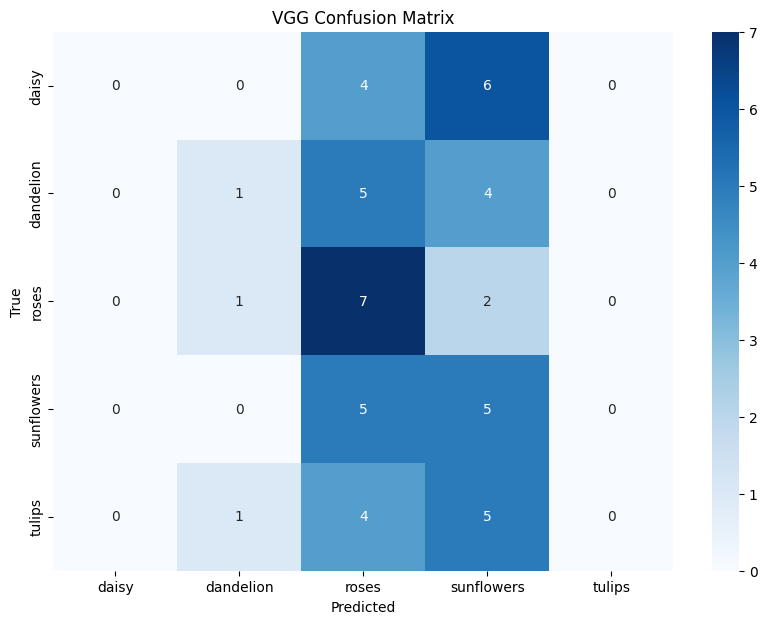

In [31]:
cm = confusion_matrix(y_true_vgg, y_pred_vgg)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("VGG Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

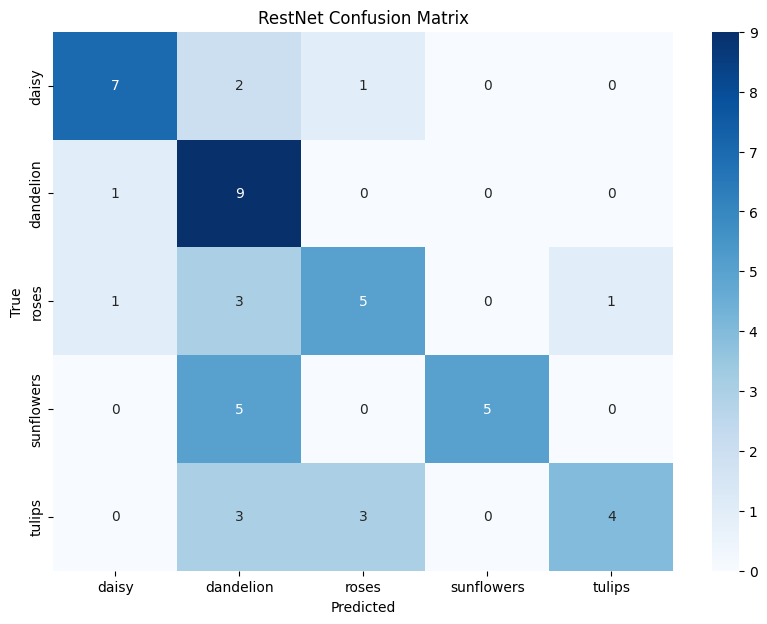

In [32]:
cm = confusion_matrix(y_true_restNet, y_pred_restNet)

plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title("RestNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

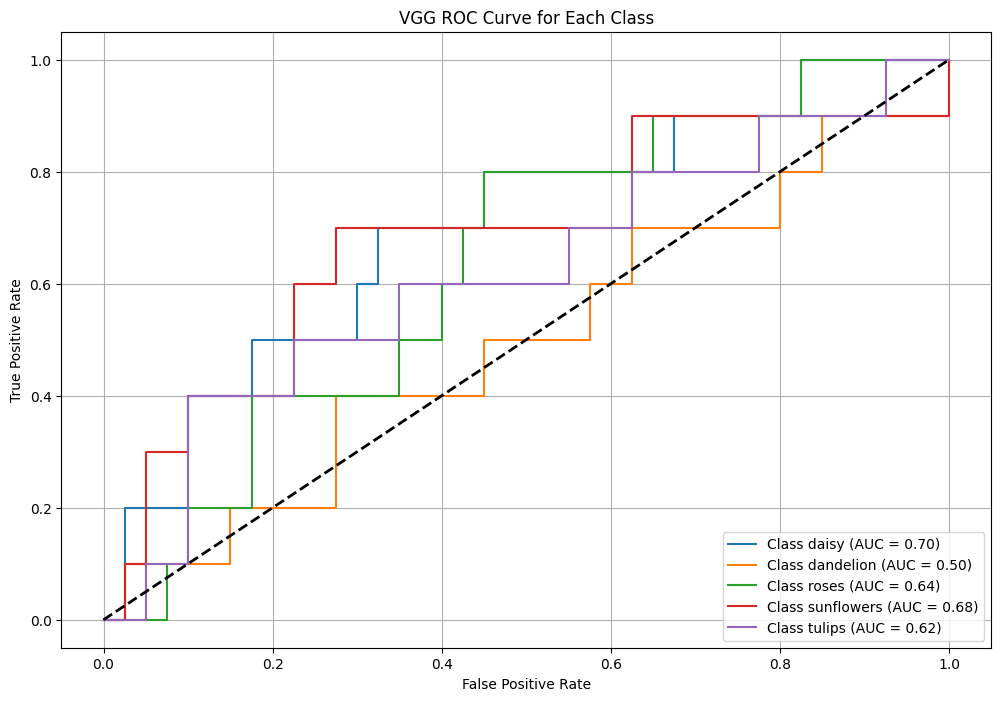

VGG Mean AUC: 0.6270


In [33]:
y_true_bin_vgg = label_binarize(y_true_vgg, classes=range(len(class_names)))

fpr_vgg = dict()
tpr_vgg = dict()
roc_auc_vgg = dict()

for i in range(len(class_names)):
    fpr_vgg[i], tpr_vgg[i], _ = roc_curve(y_true_bin_vgg[:, i], y_prob_vgg[:, i])
    roc_auc_vgg[i] = auc(fpr_vgg[i], tpr_vgg[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    plt.plot(fpr_vgg[i], tpr_vgg[i], label=f"Class {class_names[i]} (AUC = {roc_auc_vgg[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("VGG ROC Curve for Each Class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Macro-average AUC
macro_auc_vgg = np.mean(list(roc_auc_vgg.values()))
print(f"VGG Mean AUC: {macro_auc_vgg:.4f}")

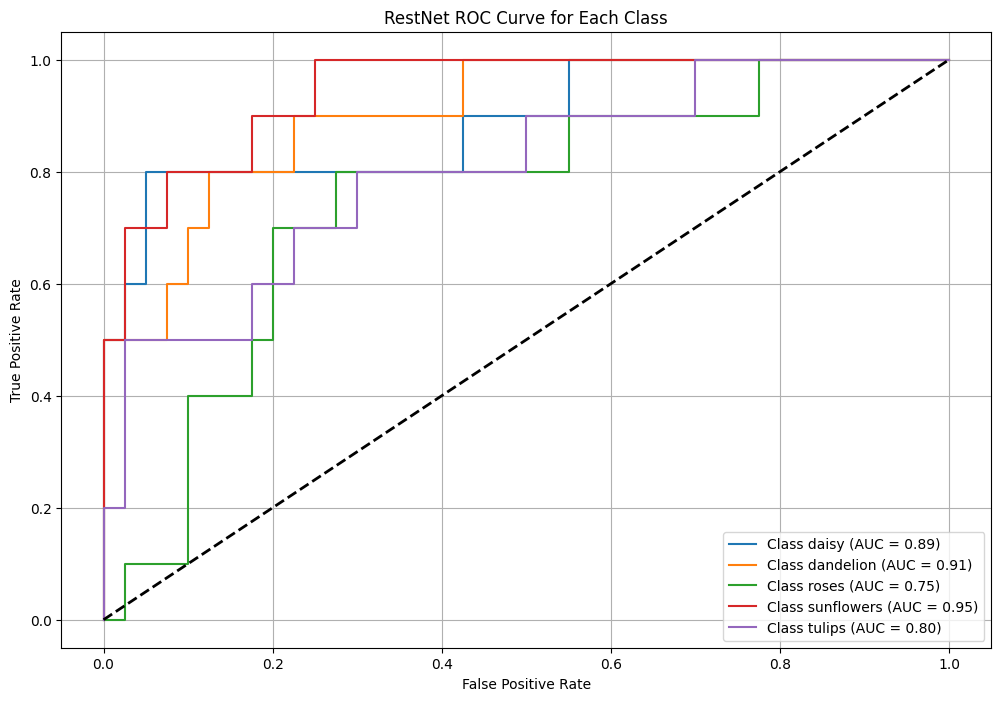

RestNet Mean AUC: 0.8585


In [34]:
y_true_bin_restNet = label_binarize(y_true_restNet, classes=range(len(class_names)))

fpr_restNet = dict()
tpr_restNet = dict()
roc_auc_restNet = dict()

for i in range(len(class_names)):
    fpr_restNet[i], tpr_restNet[i], _ = roc_curve(y_true_bin_restNet[:, i], y_prob_restNet[:, i])
    roc_auc_restNet[i] = auc(fpr_restNet[i], tpr_restNet[i])

# Plot all ROC curves
plt.figure(figsize=(12, 8))
for i in range(len(class_names)):
    plt.plot(fpr_restNet[i], tpr_restNet[i], label=f"Class {class_names[i]} (AUC = {roc_auc_restNet[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RestNet ROC Curve for Each Class")
plt.legend(loc="lower right")
plt.grid()
plt.show()

# Macro-average AUC
macro_auc_restNet = np.mean(list(roc_auc_restNet.values()))
print(f"RestNet Mean AUC: {macro_auc_restNet:.4f}")